## Crear un dataframe del csv dado

In [245]:
import pandas as pd
# DataFrame
df_csv = pd.read_csv('argentina_cars.csv')
display(df_csv)
# Paso a excel para ver mas facil los datos
df_csv.to_excel('argentina_cars.xlsx', sheet_name='Autitos', index=False)

,money,brand,model,year,color,fuel_type,door,gear,motor,body_type,kilometres,currency
0,10350000,Toyota,Corolla Cross,2022,Plateado,Nafta,5.0,Automática,NaN,SUV,500,pesos
1,10850000,Jeep,Compass,2022,Blanco,Nafta,5.0,Automática,2.4,SUV,500,pesos
2,35500,Jeep,Compass,2022,Gris oscuro,Nafta,5.0,Automática,2.4,SUV,500,dólares
3,19000,Citroën,C4 Cactus,2022,Gris oscuro,Nafta,5.0,Automática,NaN,SUV,550,dólares
4,5800000,Toyota,Corolla,2019,Gris,Nafta,4.0,Manual,1.8,Sedán,9000,pesos
...,...,...,...,...,...,...,...,...,...,...,...,...
505,5250000,Chevrolet,Tracker,2018,Gris,Nafta,5.0,Automática,1.8,SUV,52000,pesos
506,46000,Volkswagen,Amarok,2019,Gris,Diésel,4.0,Automática,3.0,Pick-Up,49000,dólares
507,3960000,Peugeot,2008,2017,Blanco,Nafta,5.0,Manual,1.6,SUV,75358,pesos
508,44900,Volkswagen,Amarok,2019,Gris,Diésel,4.0,Automática,3.0,Pick-Up,57500,dólares


## Eliminar los registros que tengan nulos

In [246]:
df_csv_clean = df_csv.dropna()
display(df_csv_clean)

,money,brand,model,year,color,fuel_type,door,gear,motor,body_type,kilometres,currency
1,10850000,Jeep,Compass,2022,Blanco,Nafta,5.0,Automática,2.4,SUV,500,pesos
2,35500,Jeep,Compass,2022,Gris oscuro,Nafta,5.0,Automática,2.4,SUV,500,dólares
4,5800000,Toyota,Corolla,2019,Gris,Nafta,4.0,Manual,1.8,Sedán,9000,pesos
5,34500,Jeep,Compass,2022,Negro,Nafta,5.0,Automática,1.3,SUV,10500,dólares
6,25000,Kia,Sorento,2014,Negro,Diésel,5.0,Automática,2.2,SUV,156000,dólares
...,...,...,...,...,...,...,...,...,...,...,...,...
505,5250000,Chevrolet,Tracker,2018,Gris,Nafta,5.0,Automática,1.8,SUV,52000,pesos
506,46000,Volkswagen,Amarok,2019,Gris,Diésel,4.0,Automática,3.0,Pick-Up,49000,dólares
507,3960000,Peugeot,2008,2017,Blanco,Nafta,5.0,Manual,1.6,SUV,75358,pesos
508,44900,Volkswagen,Amarok,2019,Gris,Diésel,4.0,Automática,3.0,Pick-Up,57500,dólares


## Pasar la columna `money` a dolares cuando `currency` sea igual a pesos. Valor del dolar = 1500. Luego eliminar la columna `currency`

In [247]:
valor_dolar = 1500

# Intento de paso de unidades, con errores
#df_csv_clean['money'] = pd.to_numeric(df_csv_clean['money'], errors='coerce')
#df_csv_clean.loc['money'] = df_csv_clean['money'].astype(int)

mask = df_csv_clean['currency'] == 'pesos'
df_csv_clean.loc[mask, 'money'] = (df_csv_clean.loc[mask, 'money'] / valor_dolar).round(0)

df_dolares = df_csv_clean.drop(columns='currency')

display(df_dolares)


,money,brand,model,year,color,fuel_type,door,gear,motor,body_type,kilometres
1,7233,Jeep,Compass,2022,Blanco,Nafta,5.0,Automática,2.4,SUV,500
2,35500,Jeep,Compass,2022,Gris oscuro,Nafta,5.0,Automática,2.4,SUV,500
4,3867,Toyota,Corolla,2019,Gris,Nafta,4.0,Manual,1.8,Sedán,9000
5,34500,Jeep,Compass,2022,Negro,Nafta,5.0,Automática,1.3,SUV,10500
6,25000,Kia,Sorento,2014,Negro,Diésel,5.0,Automática,2.2,SUV,156000
...,...,...,...,...,...,...,...,...,...,...,...
505,3500,Chevrolet,Tracker,2018,Gris,Nafta,5.0,Automática,1.8,SUV,52000
506,46000,Volkswagen,Amarok,2019,Gris,Diésel,4.0,Automática,3.0,Pick-Up,49000
507,2640,Peugeot,2008,2017,Blanco,Nafta,5.0,Manual,1.6,SUV,75358
508,44900,Volkswagen,Amarok,2019,Gris,Diésel,4.0,Automática,3.0,Pick-Up,57500


## Pasar la columna `money` del dataframe a un array de numpy con el metodo `df['money'].to_numpy()`

In [248]:
array_dolares = df_dolares['money'].to_numpy()
display(array_dolares)

array([  7233,  35500,   3867,  34500,  25000,  12300,  35500,   4533,
        38500,  20500,   3993,   1400,   1960,   1367,   2747,   2733,
        15000,   3399,   5533,   3000,   1600,   3467,   5000,   1633,
         3467,   1633,   1723,   2867,   5060,   1300,   2033,   2100,
         6260,   2193,  14900,   2100,   2067,   1833,   2500,   7527,
        46900,   1680,  43000,  17900,   3900,  32000, 185000,   1667,
         1133,   1793,   2933,   2660,   2633,   1527,   2600,   2500,
         1767,  58000,   3467,   2533,   2433,   3067,   1520,   4326,
         2967,   5660,   2400,   4500,   1860,   2127,   2127,   1967,
         2833,   2300,   2800,   3060,   2825,   1700,   7933,   1400,
         3767,   2333,   3527,   1567,   2533,   3927,  78500,   5033,
         2393,   4127,   1073,   1307,   1520,   1400,   1100,   2393,
         1433,   2533,   1033,   1063,   3133,   1867,  42900,   5000,
         4200,   2300,   6334,   2593,   2800,   4333,   2860,   8267,
      

## Hacer un grafico de la campana de Gauss con la media y la variación con la funcion random normal

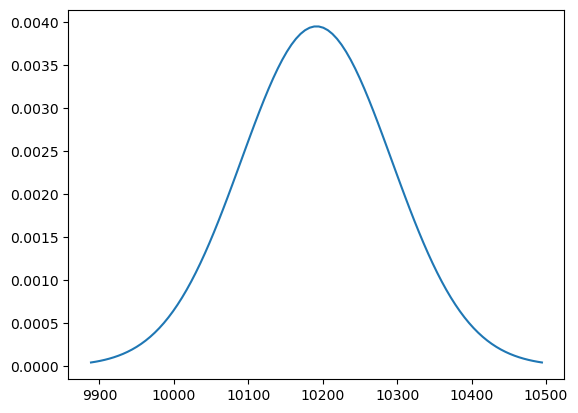

In [262]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import math

# De StackOverflow (adaptado y funca)
mu = array_dolares.mean()
variance = array_dolares.mean()
sigma = math.sqrt(variance)
x = np.linspace(mu - 3*sigma, mu + 3*sigma, 100)
plt.plot(x, stats.norm.pdf(x, mu, sigma))
plt.show()

### Otros gráficos

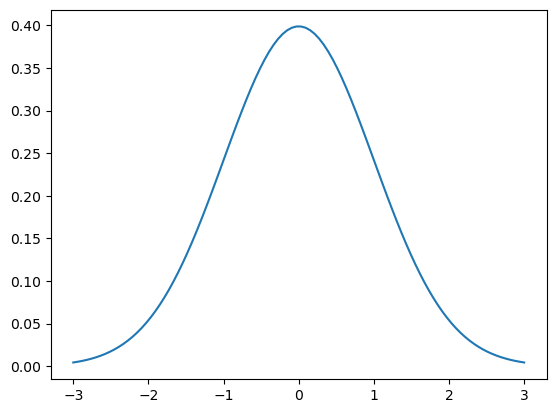

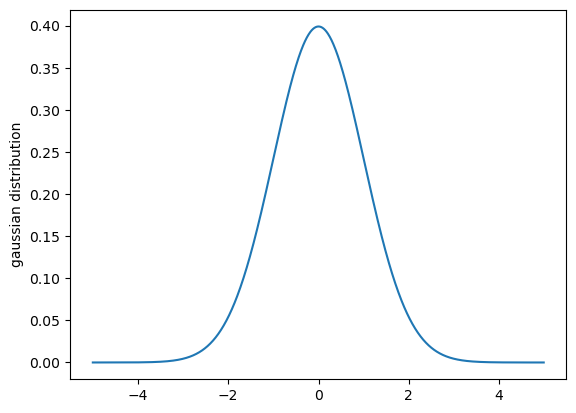

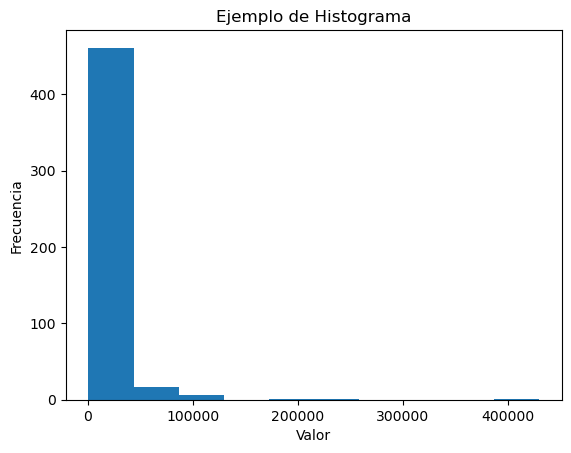

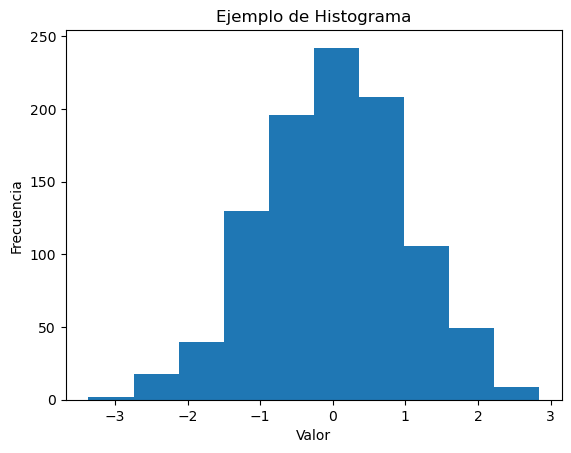

In [263]:
# De StackOverflow (el original de arriba)

mu = 0
variance = 1
sigma = math.sqrt(variance)
x = np.linspace(mu - 3*sigma, mu + 3*sigma, 100)
plt.plot(x, stats.norm.pdf(x, mu, sigma))
plt.show()

# -------------------------------------------------------------------

# De StackOverflow
mean = 0; std = 1; variance = np.square(std)
x = np.arange(-5,5,.01)
f = np.exp(-np.square(x-mean)/2*variance)/(np.sqrt(2*np.pi*variance))

plt.plot(x,f)
plt.ylabel('gaussian distribution')
plt.show()

# -------------------------------------------------------------------

# Datos
data = array_dolares
# Crear el histograma
plt.hist(data)
# Añadir título y etiquetas
plt.title("Ejemplo de Histograma")
plt.xlabel("Valor")
plt.ylabel("Frecuencia")
# Mostrar el gráfico
plt.show()

# -------------------------------------------------------------------

# Datos
data = np.random.randn(1000)
# Crear el histograma
plt.hist(data)#, bins=30)
# Añadir título y etiquetas
plt.title("Ejemplo de Histograma")
plt.xlabel("Valor")
plt.ylabel("Frecuencia")
# Mostrar el gráfico
plt.show()

## Renombrar columnas a español

In [250]:
df_dolares.columns = ['guita', 'marca', 'modelo', 'año', 'color', 'combustible', 'puertas', 'transmision', 'motor', 'estilo', 'kilometros']
display(df_dolares)

,guita,marca,modelo,año,color,combustible,puertas,transmision,motor,estilo,kilometros
1,7233,Jeep,Compass,2022,Blanco,Nafta,5.0,Automática,2.4,SUV,500
2,35500,Jeep,Compass,2022,Gris oscuro,Nafta,5.0,Automática,2.4,SUV,500
4,3867,Toyota,Corolla,2019,Gris,Nafta,4.0,Manual,1.8,Sedán,9000
5,34500,Jeep,Compass,2022,Negro,Nafta,5.0,Automática,1.3,SUV,10500
6,25000,Kia,Sorento,2014,Negro,Diésel,5.0,Automática,2.2,SUV,156000
...,...,...,...,...,...,...,...,...,...,...,...
505,3500,Chevrolet,Tracker,2018,Gris,Nafta,5.0,Automática,1.8,SUV,52000
506,46000,Volkswagen,Amarok,2019,Gris,Diésel,4.0,Automática,3.0,Pick-Up,49000
507,2640,Peugeot,2008,2017,Blanco,Nafta,5.0,Manual,1.6,SUV,75358
508,44900,Volkswagen,Amarok,2019,Gris,Diésel,4.0,Automática,3.0,Pick-Up,57500


## Agrupar los registros de la misma Marca y aplicar el promedio de precios de sus autos


In [251]:
df_grupo = (
    df_dolares.groupby('marca')['guita']
    .mean(int)
    .round(2)
    .reset_index(name='precios_promedio') # Indice limpio, para que quede bonito
)
display(df_grupo)

,marca,precios_promedio
0,Audi,95285.12
1,BMW,51149.36
2,Baic,3853.00
3,Chery,2200.00
4,Chevrolet,2570.14
5,Citroën,2232.76
6,DS,6907.00
7,Dodge,4921.50
8,Fiat,3251.91
9,Ford,7116.65


## Pasar columna `year` a formato datetime


In [252]:
# No existe mas y e a r capo

df_dolares['año'] = pd.to_datetime(df_dolares['año'])
display(df_dolares)

# !TODO Que mierda estoy viendo? que onda la fecha?

,guita,marca,modelo,año,color,combustible,puertas,transmision,motor,estilo,kilometros
1,7233,Jeep,Compass,1970-01-01 00:00:00.000002022,Blanco,Nafta,5.0,Automática,2.4,SUV,500
2,35500,Jeep,Compass,1970-01-01 00:00:00.000002022,Gris oscuro,Nafta,5.0,Automática,2.4,SUV,500
4,3867,Toyota,Corolla,1970-01-01 00:00:00.000002019,Gris,Nafta,4.0,Manual,1.8,Sedán,9000
5,34500,Jeep,Compass,1970-01-01 00:00:00.000002022,Negro,Nafta,5.0,Automática,1.3,SUV,10500
6,25000,Kia,Sorento,1970-01-01 00:00:00.000002014,Negro,Diésel,5.0,Automática,2.2,SUV,156000
...,...,...,...,...,...,...,...,...,...,...,...
505,3500,Chevrolet,Tracker,1970-01-01 00:00:00.000002018,Gris,Nafta,5.0,Automática,1.8,SUV,52000
506,46000,Volkswagen,Amarok,1970-01-01 00:00:00.000002019,Gris,Diésel,4.0,Automática,3.0,Pick-Up,49000
507,2640,Peugeot,2008,1970-01-01 00:00:00.000002017,Blanco,Nafta,5.0,Manual,1.6,SUV,75358
508,44900,Volkswagen,Amarok,1970-01-01 00:00:00.000002019,Gris,Diésel,4.0,Automática,3.0,Pick-Up,57500


## Quedarse solo con la columna `Marca` y `promedio_precios`

In [253]:
df_grupo
#df_filtrado = df_dolares[['guita', 'marca']]
#df_filtrado

,marca,precios_promedio
0,Audi,95285.12
1,BMW,51149.36
2,Baic,3853.00
3,Chery,2200.00
4,Chevrolet,2570.14
5,Citroën,2232.76
6,DS,6907.00
7,Dodge,4921.50
8,Fiat,3251.91
9,Ford,7116.65


## Graficar promedio precio por marca

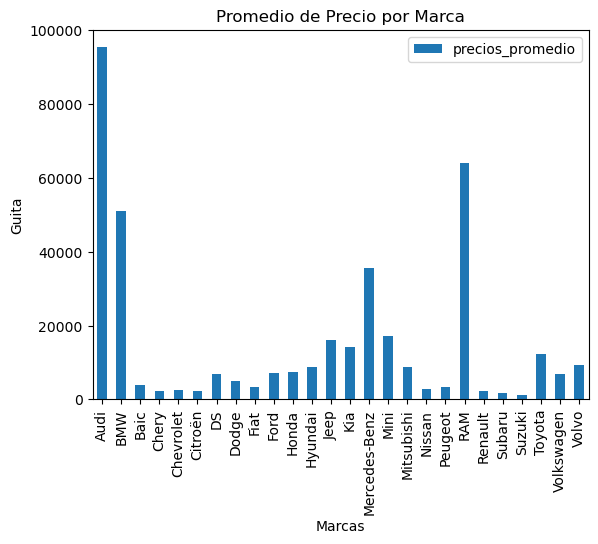

In [254]:
df_grupo.plot(x='marca', y='precios_promedio', kind='bar')
plt.title('Promedio de Precio por Marca')
plt.xlabel('Marcas')
plt.ylabel('Guita')
plt.show()

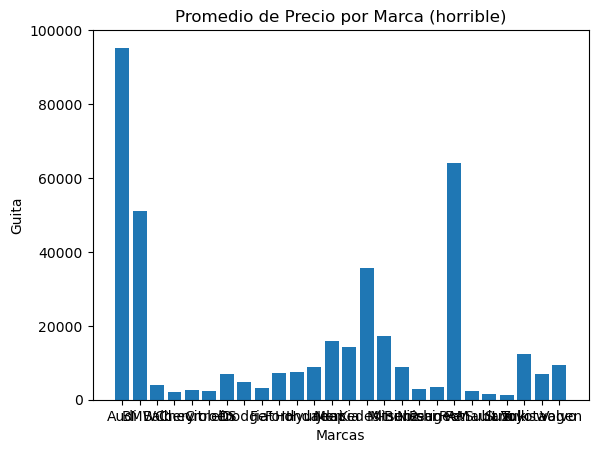

In [264]:
plt.bar(df_grupo['marca'], df_grupo['precios_promedio'])
plt.title('Promedio de Precio por Marca (horrible)')
plt.xlabel('Marcas')
plt.ylabel('Guita')
plt.show()

# Que horrible que se ve esto por favor

## Generar un nuevo excel con el dataframe creado

In [256]:
df_grupo.to_excel('precios_promedio_marcas.xlsx', index=False)